In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.linear_model import Perceptron, LogisticRegression, SGDClassifier
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, PowerTransformer

from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_LIMPOS
from src.graficos import plot_coeficientes, plot_comparar_metricas_modelos
from src.models import RANDOM_STATE
from src.models import(
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
)

sns.set_theme(palette="bright")

In [3]:
df = pd.read_parquet(DADOS_LIMPOS)

df.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
0,1001.0,153.40,2019.0,0.27760,0.04904,0.6656,0.14710,0.01587,0.2654,0.3001,...,25.38,0.11840,0.006399,0.1622,0.2419,0.03003,0.4601,10.38,0.9053,17.33
1,1326.0,74.08,1956.0,0.07864,0.01308,0.1866,0.07017,0.01340,0.1860,0.0869,...,24.99,0.08474,0.005225,0.1238,0.1812,0.01389,0.2750,17.77,0.7339,23.41
2,1203.0,94.03,1709.0,0.15990,0.04006,0.4245,0.12790,0.02058,0.2430,0.1974,...,23.57,0.10960,0.006150,0.1444,0.2069,0.02250,0.3613,21.25,0.7869,25.53
3,386.1,27.23,567.7,0.28390,0.07458,0.8663,0.10520,0.01867,0.2575,0.2414,...,14.91,0.14250,0.009110,0.2098,0.2597,0.05963,0.6638,20.38,1.1560,26.50
4,1297.0,94.44,1575.0,0.13280,0.02461,0.2050,0.10430,0.01885,0.1625,0.1980,...,22.54,0.10030,0.011490,0.1374,0.1809,0.01756,0.2364,14.34,0.7813,16.67


In [4]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [5]:
le = LabelEncoder()

y = le.fit_transform(y)

y[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [6]:
seletor_chi2 = SelectKBest(chi2, k=15)

X_chi2 = seletor_chi2.fit_transform(X,y)

X_chi2.shape

(569, 15)

In [7]:
X_chi2[:5]

array([[1.001e+03, 1.534e+02, 2.019e+03, 6.656e-01, 2.654e-01, 3.001e-01,
        7.119e-01, 1.228e+02, 8.589e+00, 1.846e+02, 1.799e+01, 1.095e+00,
        2.538e+01, 1.038e+01, 1.733e+01],
       [1.326e+03, 7.408e+01, 1.956e+03, 1.866e-01, 1.860e-01, 8.690e-02,
        2.416e-01, 1.329e+02, 3.398e+00, 1.588e+02, 2.057e+01, 5.435e-01,
        2.499e+01, 1.777e+01, 2.341e+01],
       [1.203e+03, 9.403e+01, 1.709e+03, 4.245e-01, 2.430e-01, 1.974e-01,
        4.504e-01, 1.300e+02, 4.585e+00, 1.525e+02, 1.969e+01, 7.456e-01,
        2.357e+01, 2.125e+01, 2.553e+01],
       [3.861e+02, 2.723e+01, 5.677e+02, 8.663e-01, 2.575e-01, 2.414e-01,
        6.869e-01, 7.758e+01, 3.445e+00, 9.887e+01, 1.142e+01, 4.956e-01,
        1.491e+01, 2.038e+01, 2.650e+01],
       [1.297e+03, 9.444e+01, 1.575e+03, 2.050e-01, 1.625e-01, 1.980e-01,
        4.000e-01, 1.351e+02, 5.438e+00, 1.522e+02, 2.029e+01, 7.572e-01,
        2.254e+01, 1.434e+01, 1.667e+01]])

In [8]:
seletor_chi2.get_feature_names_out()

array(['area_mean', 'area_se', 'area_worst', 'compactness_worst',
       'concave points_worst', 'concavity_mean', 'concavity_worst',
       'perimeter_mean', 'perimeter_se', 'perimeter_worst', 'radius_mean',
       'radius_se', 'radius_worst', 'texture_mean', 'texture_worst'],
      dtype=object)

In [9]:
seletor_chi2.scores_

array([5.39916559e+04, 8.75850471e+03, 1.12598432e+05, 5.40307549e+00,
       6.13785332e-01, 1.93149220e+01, 1.05440354e+01, 3.05231563e-01,
       1.34854195e+01, 1.97123536e+01, 1.04471761e+00, 3.95169151e+01,
       7.43065536e-05, 6.37136566e-03, 2.31522407e-01, 2.01110286e+03,
       2.50571896e+02, 3.66503542e+03, 2.66104917e+02, 3.46752472e+01,
       4.91689157e+02, 1.49899264e-01, 3.26620664e-03, 3.97365694e-01,
       2.57379775e-01, 8.03633831e-05, 1.29886140e+00, 9.38975081e+01,
       9.79353970e-03, 1.74449400e+02])

In [10]:
seletor_chi2.pvalues_

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 2.01012999e-002,
       4.33366115e-001, 1.10836762e-005, 1.16563638e-003, 5.80621137e-001,
       2.40424384e-004, 9.00175712e-006, 3.06726812e-001, 3.25230064e-010,
       9.93122221e-001, 9.36379753e-001, 6.30397277e-001, 0.00000000e+000,
       1.94877489e-056, 0.00000000e+000, 8.01397628e-060, 3.89553429e-009,
       6.11324751e-109, 6.98631644e-001, 9.54425121e-001, 5.28452867e-001,
       6.11926026e-001, 9.92847410e-001, 2.54421307e-001, 3.32292194e-022,
       9.21168192e-001, 7.89668299e-040])

In [11]:
seletor_chi2.get_support()

array([ True,  True,  True, False, False,  True, False, False,  True,
        True, False,  True, False, False, False,  True,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
        True, False,  True])

In [12]:
seletor_f= SelectKBest(f_classif, k=15)

X_f = seletor_f.fit_transform(X,y)

X_f.shape

(569, 15)

In [13]:
seletor_f.get_feature_names_out()

array(['area_mean', 'area_se', 'area_worst', 'compactness_mean',
       'compactness_worst', 'concave points_mean', 'concave points_worst',
       'concavity_mean', 'concavity_worst', 'perimeter_mean',
       'perimeter_se', 'perimeter_worst', 'radius_mean', 'radius_se',
       'radius_worst'], dtype=object)

In [15]:
seletor_f.scores_

array([5.73060747e+02, 2.43651586e+02, 6.61600206e+02, 3.13233079e+02,
       5.32473391e+01, 3.04341063e+02, 8.61676020e+02, 1.13262760e+02,
       9.64385393e+02, 5.33793126e+02, 3.90144816e+01, 4.36691939e+02,
       9.34592949e-02, 3.46827476e+00, 6.64439606e+01, 6.97235272e+02,
       2.53897392e+02, 8.97944219e+02, 6.46981021e+02, 2.68840327e+02,
       8.60781707e+02, 8.36511234e+01, 2.55796780e+00, 1.22472880e+02,
       6.95274435e+01, 2.41174067e-02, 1.18860232e+02, 1.18096059e+02,
       3.90947023e-02, 1.49596905e+02])

In [16]:
seletor_f.pvalues_

array([4.73456431e-088, 5.89552139e-046, 2.82884770e-097, 3.93826311e-056,
       9.97599465e-013, 7.06981635e-055, 7.10115016e-116, 3.07230877e-024,
       1.96909971e-124, 9.96655576e-084, 8.26017617e-010, 2.46466396e-072,
       7.59936804e-001, 6.30735508e-002, 2.31643245e-015, 8.43625104e-101,
       1.65190518e-047, 5.77139714e-119, 8.46594057e-096, 9.73894866e-050,
       8.48229192e-116, 1.05185036e-018, 1.10296609e-001, 6.57514363e-026,
       5.73338403e-016, 8.76641818e-001, 2.95112058e-025, 4.05863605e-025,
       8.43332029e-001, 1.07805749e-030])

In [17]:
seletor_mi= SelectKBest(mutual_info_classif, k=15)

X_mi = seletor_mi.fit_transform(X,y)

X_mi.shape

(569, 15)

In [18]:
seletor_mi.get_feature_names_out()

array(['area_mean', 'area_se', 'area_worst', 'compactness_mean',
       'compactness_worst', 'concave points_mean', 'concave points_worst',
       'concavity_mean', 'concavity_worst', 'perimeter_mean',
       'perimeter_se', 'perimeter_worst', 'radius_mean', 'radius_se',
       'radius_worst'], dtype=object)

In [19]:
seletor_mi.scores_

array([0.35758979, 0.34000696, 0.46426447, 0.20984666, 0.07765653,
       0.22688402, 0.44135611, 0.12917354, 0.43685774, 0.37315765,
       0.1181794 , 0.31495165, 0.00602651, 0.0405374 , 0.06544391,
       0.40254172, 0.27299798, 0.47444976, 0.36469152, 0.24802502,
       0.45166656, 0.07922175, 0.01742972, 0.10424604, 0.05785727,
       0.01267819, 0.09360571, 0.09592544, 0.00079694, 0.11902107])

In [20]:
seletor_mi.pvalues_

Todos com True sao seletores válidos

In [21]:
comparando_seletores = pd.DataFrame(
    {
        "chi2": seletor_chi2.get_support(),
        "f": seletor_f.get_support(),
        "mi": seletor_mi.get_support(),
    },
    index=X.columns,

)
comparando_seletores

,chi2,f,mi
area_mean,True,True,True
area_se,True,True,True
area_worst,True,True,True
compactness_mean,False,True,True
compactness_se,False,False,False
compactness_worst,True,True,True
concave points_mean,False,True,True
concave points_se,False,False,False
concave points_worst,True,True,True
concavity_mean,True,True,True


filtrando dos seletores que deram true nos 3 e avaliando qual é mais adequado ao nosso contexto

In [22]:
comparando_seletores[
    comparando_seletores["chi2"]
    & comparando_seletores ["f"]
    & comparando_seletores["mi"]
]

,chi2,f,mi
area_mean,True,True,True
area_se,True,True,True
area_worst,True,True,True
compactness_worst,True,True,True
concave points_worst,True,True,True
concavity_mean,True,True,True
concavity_worst,True,True,True
perimeter_mean,True,True,True
perimeter_se,True,True,True
perimeter_worst,True,True,True


In [23]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [24]:
preprocessamento = Pipeline(
    steps=[("scaler", PowerTransformer()), ("selector", SelectKBest(mutual_info_classif, k=15))]
)

In [25]:
classificadores = {

    "DummyClassifier": {
        "preprocessor": None,
        "classificador": DummyClassifier(strategy="stratified")
    },

    "Perceptron": {
        "preprocessor": preprocessamento,
        "classificador": Perceptron()
    },

    "LogisticRegression": {
        "preprocessor": preprocessamento,
        "classificador": LogisticRegression()
    },

    "SGDClassifier": {
        "preprocessor": preprocessamento,
        "classificador": SGDClassifier()
    },

}

In [26]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador)
    for nome_modelo, classificador in classificadores.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados

c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,DummyClassifier,0.002177,0.022179,0.491228,0.463151,0.340909,0.333333,0.348837,0.525876,0.39021,0.024356
1,DummyClassifier,0.00151,0.016493,0.535088,0.493777,0.345679,0.368421,0.325581,0.52866,0.391995,0.018004
2,DummyClassifier,0.000992,0.018853,0.526316,0.505952,0.4,0.375,0.428571,0.543651,0.391395,0.019845
3,DummyClassifier,0.001511,0.023637,0.605263,0.578373,0.470588,0.465116,0.47619,0.519841,0.378228,0.025148
4,DummyClassifier,0.002547,0.013816,0.477876,0.433769,0.271605,0.282051,0.261905,0.480885,0.363446,0.016362
5,Perceptron,0.196423,0.019065,0.938596,0.918605,0.911392,1.0,0.837209,0.987881,0.982831,0.215488
6,Perceptron,0.166799,0.017827,0.894737,0.865051,0.842105,0.969697,0.744186,0.985915,0.977328,0.184626
7,Perceptron,0.188306,0.019185,0.921053,0.922619,0.896552,0.866667,0.928571,0.982143,0.978283,0.207491
8,Perceptron,0.183037,0.01915,0.95614,0.960317,0.942529,0.911111,0.97619,0.995701,0.993515,0.202187
9,Perceptron,0.185041,0.017602,0.964602,0.952381,0.95,1.0,0.904762,0.996982,0.995172,0.202644


In [27]:
df_resultados.groupby("model").mean().sort_values("test_recall")

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
DummyClassifier,0.001747,0.018996,0.527154,0.495004,0.365756,0.364784,0.368217,0.519783,0.383055,0.020743
Perceptron,0.183921,0.018566,0.935026,0.923795,0.908516,0.949495,0.878184,0.989724,0.985426,0.202487
SGDClassifier,0.180043,0.019191,0.93678,0.929698,0.914222,0.930237,0.901218,0.986348,0.981658,0.199234
LogisticRegression,0.201186,0.020756,0.952585,0.947818,0.935613,0.944606,0.929125,0.992078,0.989293,0.221943


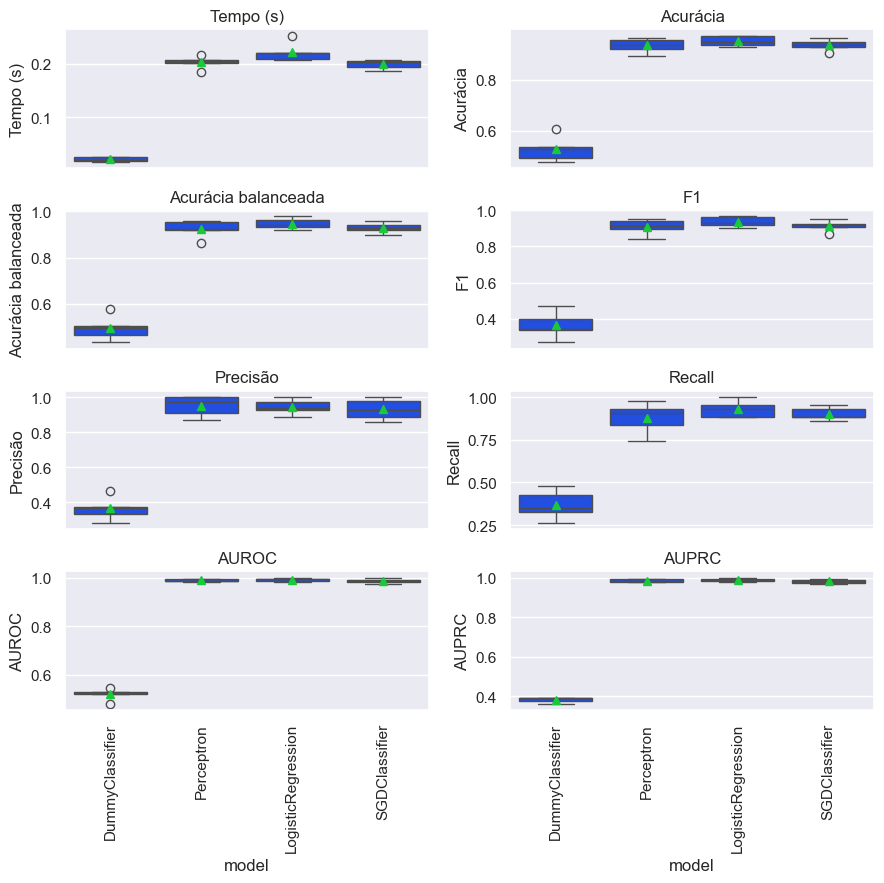

In [28]:
plot_comparar_metricas_modelos(df_resultados)

In [29]:
param_grid = {
    "clf__C": [0.1, 1, 10, 100],
    "clf__penalty": ["11", "12", "elasticnet", None],
    "clf__class_weight": [None, "balanced"],
    "clf__l1_ratio": [ 0.1, 0.25, 0.5, 0.75, 0.9],
}

In [30]:
clf = LogisticRegression(solver="saga", random_state=RANDOM_STATE)

grid_search = grid_search_cv_classificador(
    clf, param_grid, kf, preprocessamento, refit_metric="recall"
)

grid_search

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        Pipeline(steps=[('scaler',
                                                         PowerTransformer()),
                                                        ('selector',
                                                         SelectKBest(k=15,
                                                                     score_func=<function mutual_info_classif at 0x00000259204587C0>))])),
                                       ('clf',
                                        LogisticRegression(random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10, 100],
                         'clf__class_weight': [None, 'balanced'],
                         'clf__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
                         'clf__penalty': ['11', '12', 'elasticnet', None]},
             refit='recall',
             scoring=['accuracy', 'balanced_accuracy', 'f1', 'precision',
                      'recall', 'roc_auc', 'average_precision'],
             verbose=1)

In [31]:
grid_search.fit(X, y)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
400 fits failed out of a total of 800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
69 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\carol\anaconda3\envs\machine_learn

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        Pipeline(steps=[('scaler',
                                                         PowerTransformer()),
                                                        ('selector',
                                                         SelectKBest(k=15,
                                                                     score_func=<function mutual_info_classif at 0x00000259204587C0>))])),
                                       ('clf',
                                        LogisticRegression(random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10, 100],
                         'clf__class_weight': [None, 'balanced'],
                         'clf__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
                         'clf__penalty': ['11', '12', 'elasticnet', None]},
             refit='recall',
             scoring=['accuracy', 'balanced_accuracy', 'f1', 'precision',
                      'recall', 'roc_auc', 'average_precision'],
             verbose=1)

In [32]:
grid_search.best_params_

{'clf__C': 1,
 'clf__class_weight': 'balanced',
 'clf__l1_ratio': 0.1,
 'clf__penalty': 'elasticnet'}

In [33]:
grid_search.best_score_

np.float64(0.9527131782945737)

In [34]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', PowerTransformer()),
                                 ('selector',
                                  SelectKBest(k=15,
                                              score_func=<function mutual_info_classif at 0x00000259204587C0>))])),
                ('clf',
                 LogisticRegression(C=1, class_weight='balanced', l1_ratio=0.1,
                                    penalty='elasticnet', random_state=42,
                                    solver='saga'))])

In [35]:
grid_search.best_estimator_["preprocessor"].get_feature_names_out()

array(['area_mean', 'area_se', 'area_worst', 'compactness_mean',
       'compactness_worst', 'concave points_mean', 'concave points_worst',
       'concavity_mean', 'concavity_worst', 'perimeter_mean',
       'perimeter_se', 'perimeter_worst', 'radius_mean', 'radius_se',
       'radius_worst'], dtype=object)

In [36]:
grid_search.best_estimator_["clf"].coef_

array([[-0.30602353,  1.18765327,  1.43240521, -1.44185048,  0.25658963,
         1.33379021,  1.5579611 ,  0.        ,  1.2586317 , -0.40012119,
        -0.33616829,  0.87749087, -0.47084293,  0.5206753 ,  1.2158034 ]])

In [37]:
coefs = dataframe_coeficientes(
    grid_search.best_estimator_["clf"].coef_[0],
    grid_search.best_estimator_["preprocessor"].get_feature_names_out()
)

coefs

,coeficiente
compactness_mean,-1.441850
radius_mean,-0.470843
perimeter_mean,-0.400121
perimeter_se,-0.336168
area_mean,-0.306024
concavity_mean,0.000000
compactness_worst,0.256590
radius_se,0.520675
perimeter_worst,0.877491
area_se,1.187653


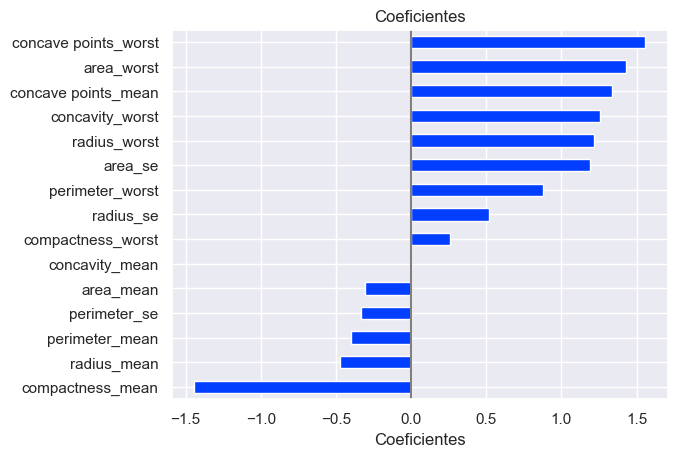

In [38]:
plot_coeficientes(coefs)

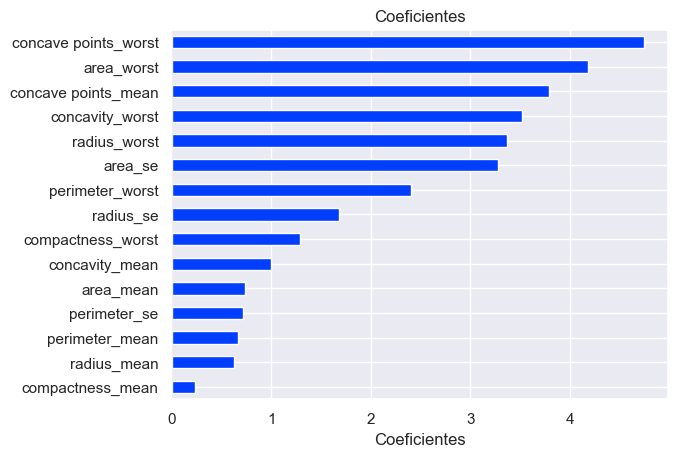

In [39]:
coefs_odds = coefs.copy()
coefs_odds["coeficiente"] = np.exp(coefs_odds["coeficiente"])

plot_coeficientes(coefs_odds)

In [40]:
coefs_odds

,coeficiente
compactness_mean,0.236490
radius_mean,0.624476
perimeter_mean,0.670239
perimeter_se,0.714503
area_mean,0.736369
concavity_mean,1.000000
compactness_worst,1.292515
radius_se,1.683164
perimeter_worst,2.404858
area_se,3.279376


In [41]:
X_scaled = grid_search.best_estimator_["preprocessor"].transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=grid_search.best_estimator_["preprocessor"].get_feature_names_out())

X_scaled.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_worst,concave points_mean,concave points_worst,concavity_mean,concavity_worst,perimeter_mean,perimeter_se,perimeter_worst,radius_mean,radius_se,radius_worst
0,1.126421,1.876109,1.652210,2.165938,1.942737,1.848558,1.935654,1.862988,1.730182,1.259822,1.973081,1.810506,1.134881,1.892785,1.619635
1,1.633946,1.276861,1.610022,-0.384102,-0.296580,0.820609,1.101594,0.291976,0.070746,1.528723,0.732407,1.430616,1.619346,0.958616,1.578689
2,1.461645,1.496107,1.425307,1.163977,1.209701,1.683104,1.722744,1.403673,1.005512,1.454664,1.213029,1.321941,1.464796,1.457817,1.419757
3,-0.836238,0.045515,-0.436860,2.197843,2.282276,1.423004,1.862378,1.642391,1.675087,-0.514886,0.756164,-0.039480,-0.759262,0.791676,-0.083692
4,1.595120,1.499885,1.309486,0.762392,-0.131829,1.410929,0.807077,1.407479,0.817474,1.583340,1.451685,1.316582,1.571260,1.479006,1.293727


In [42]:
df_scaled = pd.concat([X_scaled, pd.Series(y, name="diagnosis")], axis=1)

df_scaled.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_worst,concave points_mean,concave points_worst,concavity_mean,concavity_worst,perimeter_mean,perimeter_se,perimeter_worst,radius_mean,radius_se,radius_worst,diagnosis
0,1.126421,1.876109,1.652210,2.165938,1.942737,1.848558,1.935654,1.862988,1.730182,1.259822,1.973081,1.810506,1.134881,1.892785,1.619635,1
1,1.633946,1.276861,1.610022,-0.384102,-0.296580,0.820609,1.101594,0.291976,0.070746,1.528723,0.732407,1.430616,1.619346,0.958616,1.578689,1
2,1.461645,1.496107,1.425307,1.163977,1.209701,1.683104,1.722744,1.403673,1.005512,1.454664,1.213029,1.321941,1.464796,1.457817,1.419757,1
3,-0.836238,0.045515,-0.436860,2.197843,2.282276,1.423004,1.862378,1.642391,1.675087,-0.514886,0.756164,-0.039480,-0.759262,0.791676,-0.083692,1
4,1.595120,1.499885,1.309486,0.762392,-0.131829,1.410929,0.807077,1.407479,0.817474,1.583340,1.451685,1.316582,1.571260,1.479006,1.293727,1


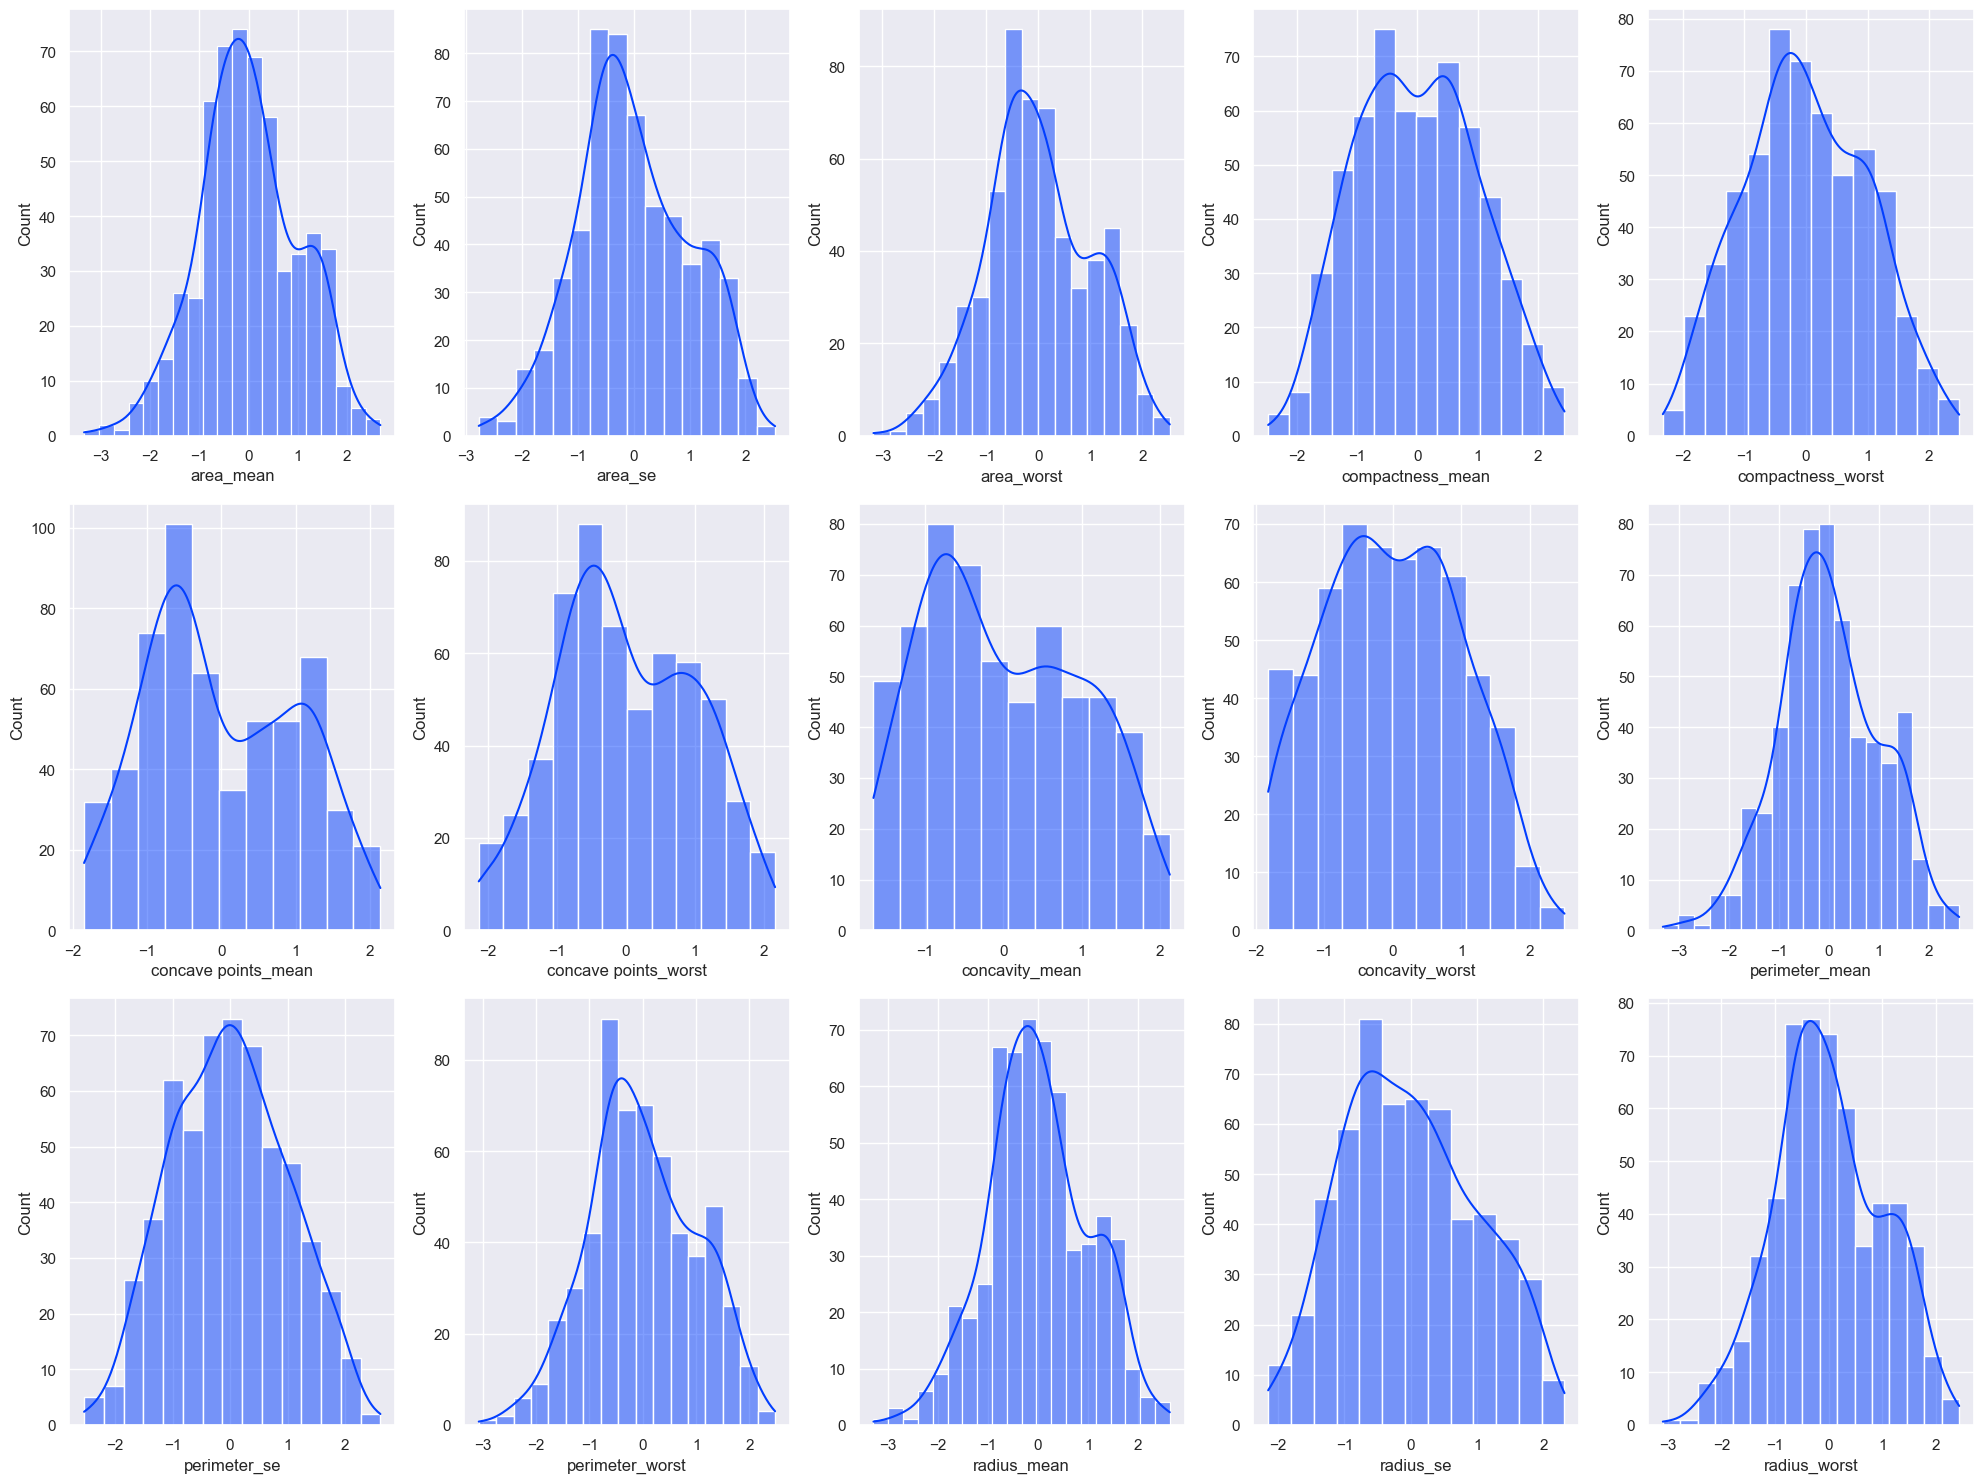

In [45]:
fig, axs = plt.subplots(3, 5, figsize=(20, 15))

for ax, coluna in zip(axs.flatten(), X_scaled.columns):
    sns.histplot(x=coluna, ax=ax, data=df_scaled, kde=True)

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

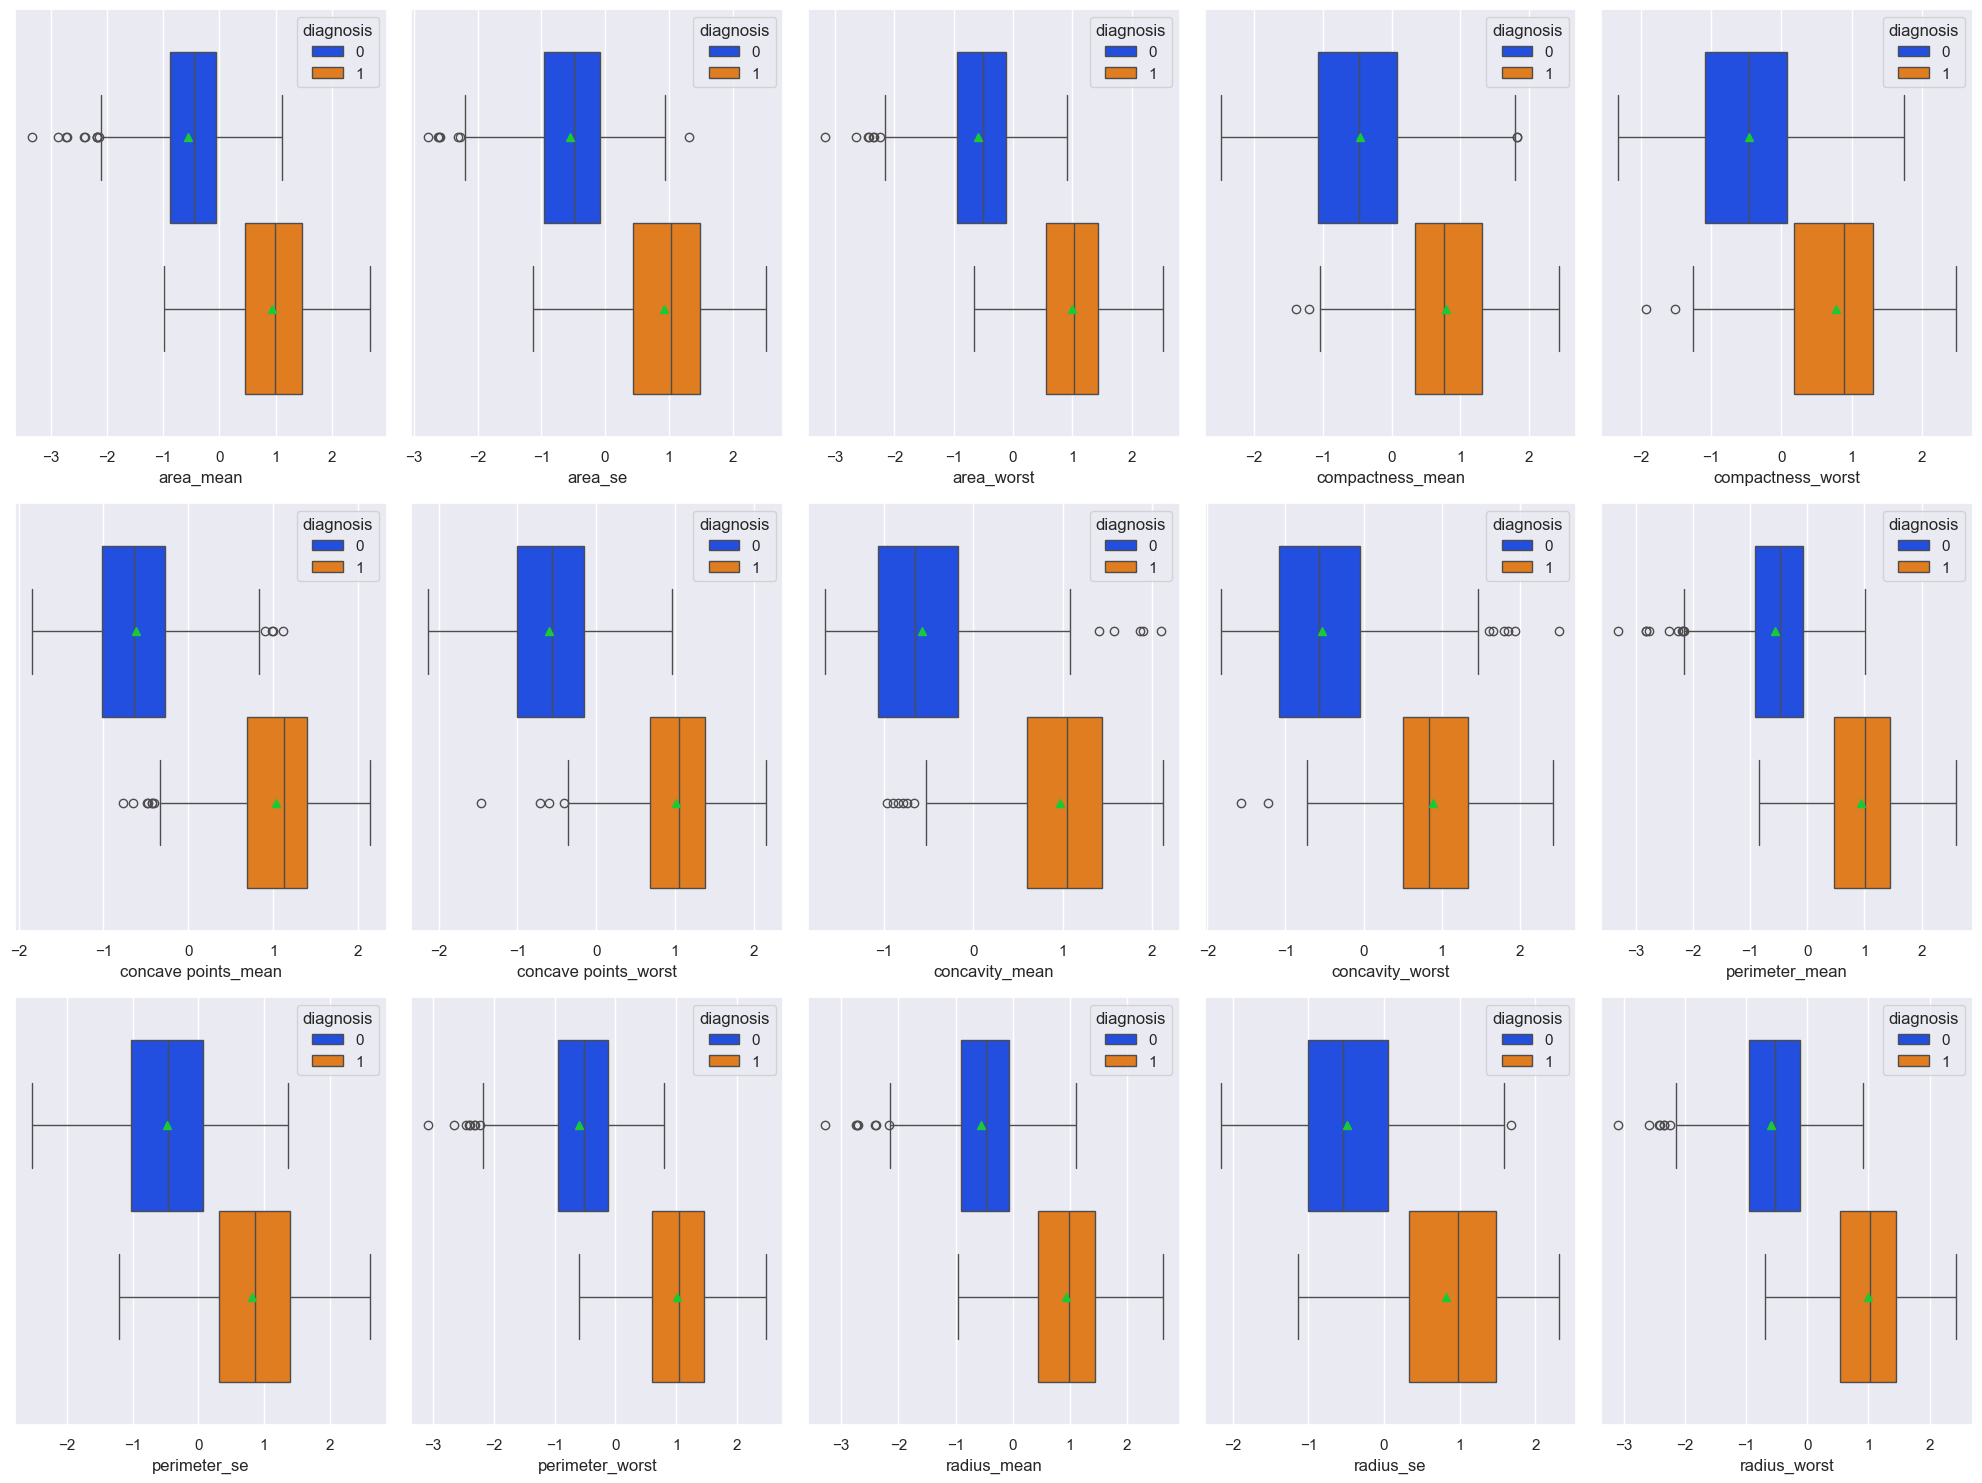

In [46]:
fig, axs = plt.subplots(3, 5, figsize=(20,15))

for ax, coluna in zip(axs.flatten(),X_scaled.columns):
    sns.boxplot(x=coluna, ax=ax, data=df_scaled, showmeans=True, hue="diagnosis")

plt.tight_layout()
plt.show